In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, glob, json
import numpy as np
import pandas as pd
import cv2
import sys

Mounted at /content/drive


In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/Projects/diabetic retinopathy/diabetic-retinopathy-xai"
sys.path.append(f"{PROJECT_ROOT}/eval")

In [ ]:
from aopc import run_aopc

for model in ["efficientnetb4", "resnet50"]:
    for method in ["gradcam", "lime", "shap"]:
        run_aopc(model_name=model, method_name=method)

Device: cuda
IDRiD_55: del_auc=0.5156, ins_auc=0.2321
IDRiD_56: del_auc=0.4097, ins_auc=0.5643
IDRiD_57: del_auc=0.1592, ins_auc=0.5290
IDRiD_58: del_auc=0.5939, ins_auc=0.3578
IDRiD_59: del_auc=0.6777, ins_auc=0.7695
IDRiD_60: del_auc=0.4941, ins_auc=0.5888
IDRiD_61: del_auc=0.5367, ins_auc=0.4906
IDRiD_62: del_auc=0.3565, ins_auc=0.2264
IDRiD_63: del_auc=0.7424, ins_auc=0.7351
IDRiD_64: del_auc=0.7440, ins_auc=0.5914
IDRiD_65: del_auc=0.1702, ins_auc=0.2315
IDRiD_66: del_auc=0.5003, ins_auc=0.5344
IDRiD_67: del_auc=0.2904, ins_auc=0.4781
IDRiD_68: del_auc=0.5474, ins_auc=0.2534
IDRiD_69: del_auc=0.5174, ins_auc=0.4755
IDRiD_70: del_auc=0.4421, ins_auc=0.4242
IDRiD_71: del_auc=0.3939, ins_auc=0.2584
IDRiD_72: del_auc=0.7370, ins_auc=0.3964
IDRiD_73: del_auc=0.5160, ins_auc=0.2257
IDRiD_74: del_auc=0.3744, ins_auc=0.3194
IDRiD_75: del_auc=0.5003, ins_auc=0.4657
IDRiD_76: del_auc=0.2999, ins_auc=0.2439
IDRiD_77: del_auc=0.2861, ins_auc=0.1420
IDRiD_78: del_auc=0.2988, ins_auc=0.4939
IDR

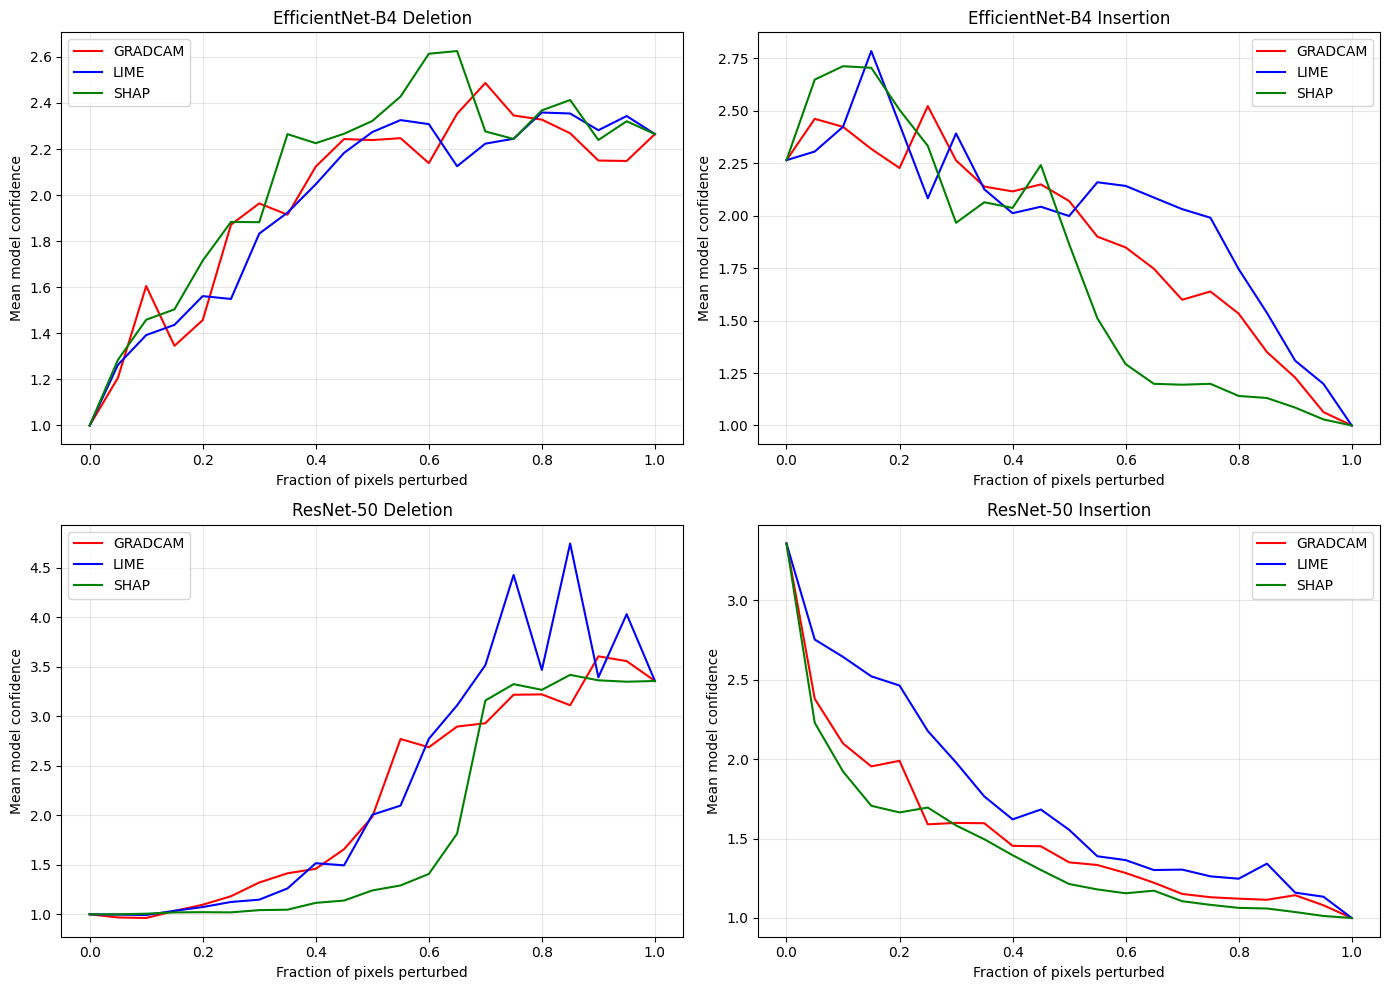

Saved: /content/drive/MyDrive/Projects/diabetic retinopathy/diabetic-retinopathy-xai/results/figures/aopc_curves.png


In [ ]:
# plotting the curve

import numpy as np
import matplotlib.pyplot as plt
import os

SCORES_DIR = os.path.join(PROJECT_ROOT, "results/scores")

models = ["efficientnetb4", "resnet50"]
methods = ["gradcam", "lime", "shap"]
colors = {"gradcam": "red", "lime": "blue", "shap": "green"}
steps = np.linspace(0, 1, 21)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
titles = ["EfficientNet-B4 Deletion", "EfficientNet-B4 Insertion",
          "ResNet-50 Deletion", "ResNet-50 Insertion"]

for i, model in enumerate(models):
    for j, mode in enumerate(["deletion", "insertion"]):
        ax = axes[i][j]
        ax.set_title(titles[i*2 + j])
        for method in methods:
            npz_path = os.path.join(SCORES_DIR, f"aopc_curves_{model}_{method}.npz")
            data = np.load(npz_path, allow_pickle=True)
            curves = data["insertion"].item() if mode == "deletion" else data["deletion"].item()

            raw = np.stack(list(curves.values()))
            norm_factor = raw[:, 0:1] if mode == "deletion" else raw[:, -1:]
            normalized = raw / (norm_factor + 1e-8)
            mean_curve = np.mean(normalized, axis=0)

            ax.plot(steps, mean_curve, label=method.upper(), color=colors[method])
        ax.set_xlabel("Fraction of pixels perturbed")
        ax.set_ylabel("Mean model confidence")
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
out = os.path.join(PROJECT_ROOT, "results/figures/aopc_curves.png")
os.makedirs(os.path.dirname(out), exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out)